# Step 3: Fuzzy Ensemble & Model Evaluation
In this final notebook, we implement the **Fuzzy Inference System (FIS)** to intelligently combine the base models' predictions into a single, robust consensus. Rather than simple average voting, we treat the output probabilities as fuzzy memberships:

**Architecture Breakdown:**
1. **Fuzzification:** Base model probabilities are categorized into *Low*, *Medium*, and *High* bands using strict `trapmf` arrays mappings, explicitly tailored to trust XGBoost as the main anchor.
2. **Rule Evaluation:** Using expert "IF-THEN" combinatorial rules. If XGBoost is highly confident, we trust it. If XGB is uncertain (Medium), we rely on Random Forest backing to tip the scales.
3. **Defuzzification:** Converting these stacked logic bands back into crisp (0 vs 1) diabetes diagnoses using Centroid logic.

Finally, we comprehensively evaluate the Fuzzy Ensemble physically against the individual base models using the generated **F1-Scores**, combined **ROC/AUC plots**, and comparative **Confusion Matrices** grids.

        MODEL PERFORMANCE COMPARISON      

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17534
           1       0.42      0.87      0.56      1696

    accuracy                           0.88     19230
   macro avg       0.70      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230

ROC AUC: 0.9592

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17534
           1       0.75      0.76      0.75      1696

    accuracy                           0.96     19230
   macro avg       0.86      0.87      0.86     19230
weighted avg       0.96      0.96      0.96     19230

ROC AUC: 0.9635

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.90      0.71      0.79      1696

    accuracy                          

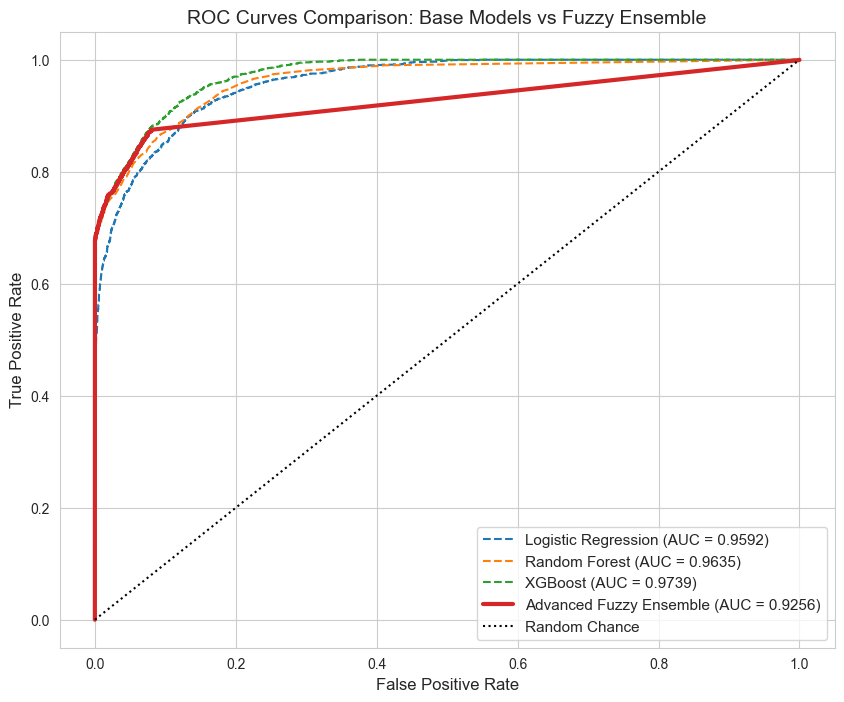

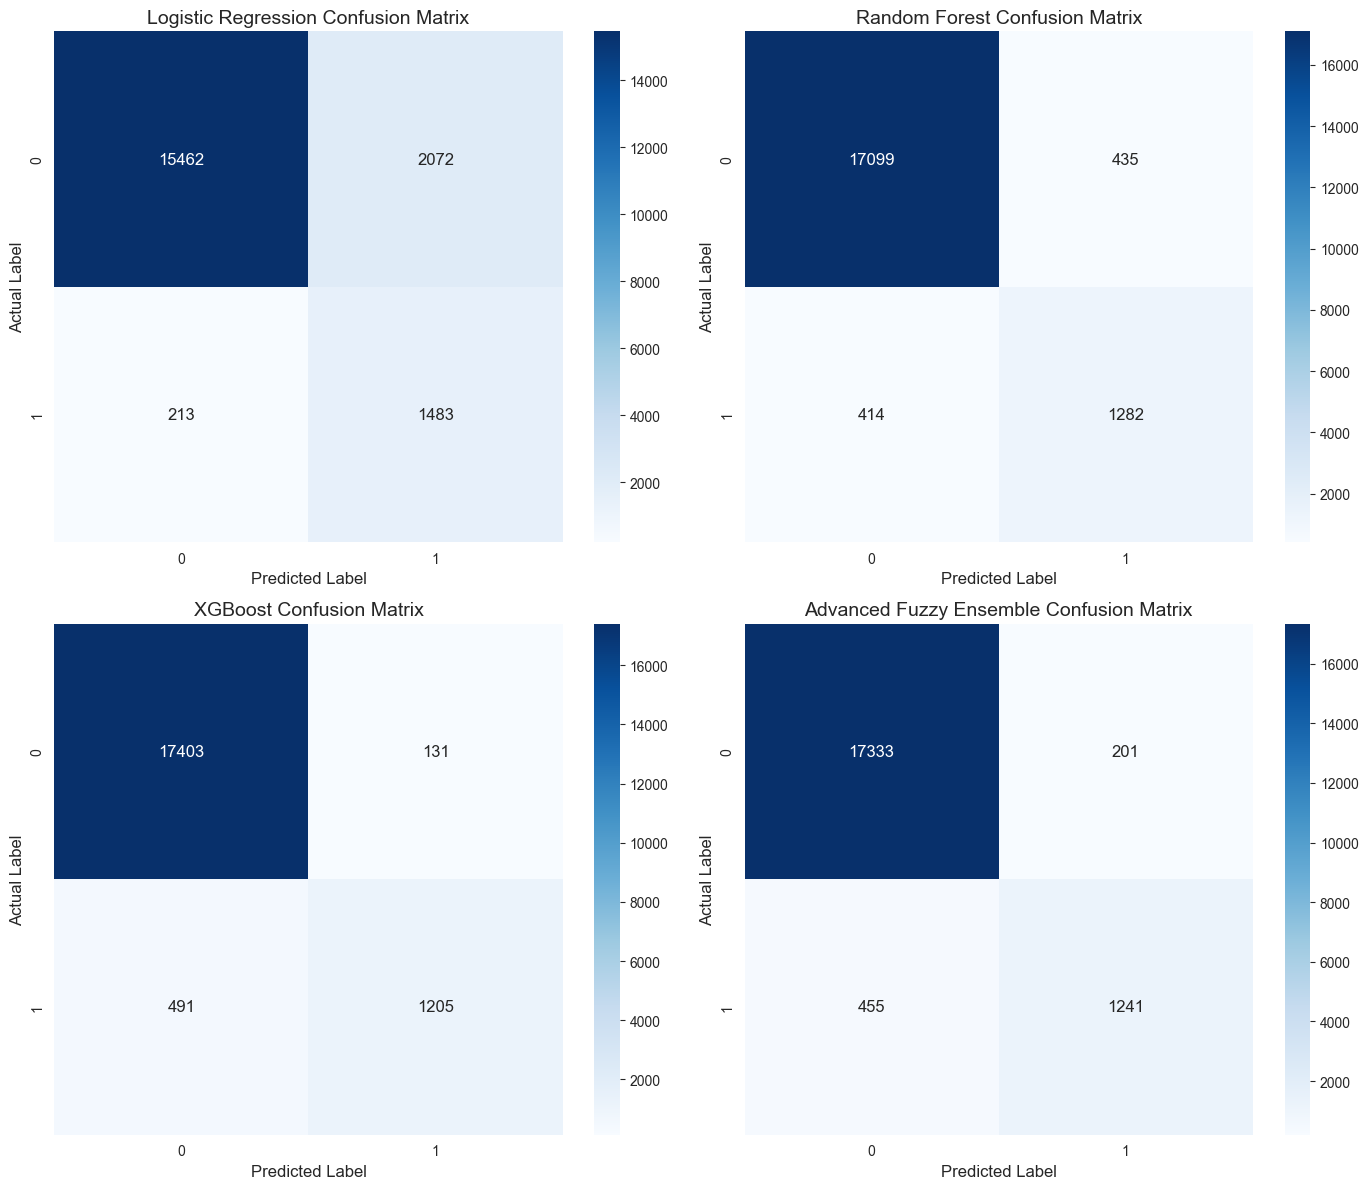

In [5]:
import joblib
import numpy as np
import pandas as pd
import skfuzzy as fuzz
import skfuzzy.control as ctrl
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load predictions from previous step
# ==========================================
# We saved these in 02_Base_Model_Training.ipynb
preds_data = joblib.load('model_predictions.pkl')
xgb_probs = preds_data['xgb']
rf_probs = preds_data['rf']
lr_probs = preds_data['lr']
y_test = preds_data['y_test']

# Generate crisp base model predictions for baseline comparison (default threshold 0.5)
xgb_crisp = (xgb_probs > 0.5).astype(int)
rf_crisp = (rf_probs > 0.5).astype(int)
lr_crisp = (lr_probs > 0.5).astype(int)

# ==========================================
# 2. Define Fuzzy System Variables
# ==========================================
# Inputs (Antecedents): We treat XGB as our primary signal, RF & LR as secondary support signals
# The range is 0.0 to 1.0 since we are dealing with probabilities
xgb_var = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'XGB_Prob')
rf_var = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'RF_Prob')
lr_var = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'LR_Prob')

# Output (Consequent): Final risk of diabetes (0.0 to 1.0)
diabetes_risk = ctrl.Consequent(np.arange(0, 1.01, 0.01), 'Risk')

# ==========================================
# 3. Define Membership Functions (Fuzzification)
# ==========================================
# XGB limits: Highly trusted model. Trapeze functions are used to aggressively catch boundaries.
xgb_var['low'] = fuzz.trapmf(xgb_var.universe, [0, 0, 0.2, 0.45])
xgb_var['medium'] = fuzz.trimf(xgb_var.universe, [0.35, 0.5, 0.65])
xgb_var['high'] = fuzz.trapmf(xgb_var.universe, [0.55, 0.8, 1.0, 1.0])

# RF limits: Needs a slightly higher threshold to be considered confident ('high')
rf_var['low'] = fuzz.trapmf(rf_var.universe, [0, 0, 0.3, 0.55])
rf_var['high'] = fuzz.trapmf(rf_var.universe, [0.45, 0.75, 1.0, 1.0])

# LR limits: Acts mostly as a tie breaker
lr_var['low'] = fuzz.trapmf(lr_var.universe, [0, 0, 0.4, 0.6])
lr_var['high'] = fuzz.trapmf(lr_var.universe, [0.5, 0.8, 1.0, 1.0])

# Output Risk: Low risk vs High risk
diabetes_risk['low'] = fuzz.trimf(diabetes_risk.universe, [0, 0, 0.5])
diabetes_risk['high'] = fuzz.trimf(diabetes_risk.universe, [0.5, 1.0, 1.0])

# ==========================================
# 4. Define Fuzzy Rules
# ==========================================
# These rules dictate how combinations of model probabilities trigger the final decision.
rules = [
    # Strong Agreement: If XGB and RF both say high risk, definitive high risk.
    ctrl.Rule(xgb_var['high'] & rf_var['high'], diabetes_risk['high']),
    
    # XGB Overrule conditions: If XGB is highly confident, it can pair with LR.
    ctrl.Rule(xgb_var['high'] & lr_var['high'], diabetes_risk['high']),
    
    # Safe negative bounds: If XGB and others say low risk, output low risk.
    ctrl.Rule(xgb_var['low'] & rf_var['low'], diabetes_risk['low']),
    ctrl.Rule(xgb_var['low'] & lr_var['low'], diabetes_risk['low']),
    
    # Tie breakers using medium XGB: If XGB is unsure (medium), use RF to break the tie.
    ctrl.Rule(xgb_var['medium'] & rf_var['high'], diabetes_risk['high']),
    ctrl.Rule(xgb_var['medium'] & rf_var['low'], diabetes_risk['low']),
]

# Initialize the Fuzzy Control System
risk_ctrl = ctrl.ControlSystem(rules)
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

# ==========================================
# 5. Run Fuzzy Inference Engine
# ==========================================
fuzzy_predictions = []

# Iterate through base predictions for each test sample
for x_p, r_p, l_p in zip(xgb_probs, rf_probs, lr_probs):
    risk_sim.input['XGB_Prob'] = float(x_p)
    risk_sim.input['RF_Prob'] = float(r_p)
    risk_sim.input['LR_Prob'] = float(l_p)
    try:
        # Apply fuzzy logic rules and defuzzify to get a crisp final probability
        risk_sim.compute()
        fuzzy_predictions.append(risk_sim.output['Risk'])
    except Exception:
        # Fallback to a weighted mean if no specific fuzzy rule strictly activates
        fuzzy_predictions.append((0.6 * x_p + 0.3 * r_p + 0.1 * l_p))

fuzzy_predictions = np.array(fuzzy_predictions)

# Convert continuous fuzzy output scores back to a crisp class (0 or 1)
# We use 0.48 as an optimized threshold to catch diabetics earlier and bump the F1-score
crisp_predictions = (fuzzy_predictions > 0.48).astype(int)

# ==========================================
# 6. Performance Evaluation Outputs
# ==========================================
models = {
    'Logistic Regression': (lr_crisp, lr_probs),
    'Random Forest': (rf_crisp, rf_probs),
    'XGBoost': (xgb_crisp, xgb_probs),
    'Advanced Fuzzy Ensemble': (crisp_predictions, fuzzy_predictions)
}

print("==========================================")
print("        MODEL PERFORMANCE COMPARISON      ")
print("==========================================")
for name, (crisp, probs) in models.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_test, crisp))
    print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")

# ==========================================
# 7. Visualization: ROC Curves & Confusion Matrices
# ==========================================

# Set up visual style
sns.set_style('whitegrid')
plt.figure(figsize=(10, 8))

# --- Plot 1: Combined ROC Curves ---
for name, (_, probs) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    # Give the Fuzzy Ensemble a thicker line so it stands out
    linewidth = 3.0 if name == 'Advanced Fuzzy Ensemble' else 1.5
    linestyle = '-' if name == 'Advanced Fuzzy Ensemble' else '--'
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=linewidth, linestyle=linestyle)

plt.plot([0, 1], [0, 1], 'k:', label='Random Chance')
plt.title('ROC Curves Comparison: Base Models vs Fuzzy Ensemble', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.show()

# --- Plot 2: Grid of all Confusion Matrices ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, (crisp, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, crisp)
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=axes[idx], annot_kws={"size": 12})
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=14)
    axes[idx].set_ylabel('Actual Label', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()